In [1]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point
import networkx as nx
import numpy as np
import pandas as pd
import ast
from pprint import pprint
import matplotlib.pyplot as plt
import pyproj
from shapely.geometry import LineString
from collections import defaultdict


# mappymatch imports
from mappymatch.constructs.trace import Trace
from mappymatch.maps.nx.nx_map import NxMap
from mappymatch.matchers.lcss.lcss import LCSSMatcher
pd.set_option('future.no_silent_downcasting', True)


In [2]:
place ="Porto, Portugal"
porto_G_obj = ox.graph_from_place(place, network_type='drive', which_result=2)

# EPSG:32629 (WGS 84 / UTM Zone 29N), which is the local crs for porto.
# EPSG 4326 is the lat/long crs
# EPSG 3857 is the mercator projection crs, only one compatible with lcss.


porto_crs = 3857
G_proj = ox.project_graph(porto_G_obj, to_crs = porto_crs)

print(porto_G_obj.graph["crs"])
print(G_proj.graph["crs"])

epsg:4326
EPSG:3857


In [3]:
# Create the smaller dataset

# traj_df = pd.read_csv("train.csv", nrows=15, index_col=0)
# traj_df.to_csv( "train_15.csv")

In [4]:
# read some of the trajectory data
# data is of the ofrm long, lat
traj_df = pd.read_csv("train_15.csv", index_col=0)

polylines = traj_df["POLYLINE"].to_numpy()
trajectories = []

for line in polylines:
    traj = ast.literal_eval(line)  # list of (lon, lat)
    trip_gdf = gpd.GeoDataFrame(
        geometry=[Point(lon, lat) for lon, lat in traj],
        crs="EPSG:4326"
    ).to_crs(porto_crs)  # reproject immediately
    trajectories.append(trip_gdf)


In [5]:
trajectories

[                           geometry
 0     POINT (-959422.95 5033222.33)
 1    POINT (-959406.92 5033217.009)
 2   POINT (-959610.301 5033384.635)
 3   POINT (-959813.682 5033577.542)
 4   POINT (-960014.057 5033660.028)
 5   POINT (-960317.625 5033719.896)
 6   POINT (-960394.769 5033707.923)
 7   POINT (-960712.364 5033783.757)
 8   POINT (-960992.889 5034036.543)
 9   POINT (-960880.679 5034229.462)
 10  POINT (-960680.304 5034548.786)
 11  POINT (-960588.131 5034671.197)
 12  POINT (-960590.135 5034675.188)
 13  POINT (-960552.064 5034817.559)
 14   POINT (-960541.043 5034842.84)
 15  POINT (-960549.058 5034864.129)
 16   POINT (-960780.491 5034888.08)
 17  POINT (-960945.801 5034938.642)
 18  POINT (-960814.555 5035155.531)
 19  POINT (-960779.489 5035158.192)
 20  POINT (-960779.489 5035159.523)
 21  POINT (-960779.489 5035156.861)
 22  POINT (-960780.491 5035155.531),
                            geometry
 0   POINT (-961783.369 5035944.622)
 1   POINT (-961839.474 5035951.275)


In [6]:
fig, ax = ox.plot_graph(
    G_proj,
    figsize=(15, 10),
    node_size=6,
    node_color="white",
    node_zorder=1,
    edge_color="lightgray",
    edge_linewidth=0.8,
    show=False,
    close=False,
)

# Choose colors manually to avoid light shades
vivid_colors = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
    "#46f0f0", "#f032e6", "#bcf60c", "#fabebe", "#008080",
    "#e6beff", "#9a6324", "#fffac8", "#800000", "#aaffc3"
]

for i, traj in enumerate(trajectories):
    x, y = traj.geometry.x, traj.geometry.y
    color =vivid_colors[i]
    ax.plot(
        x,
        y,
        color=color,
        marker="o",
        markersize=4,
        markeredgecolor="black",
        markeredgewidth=0.3,
        linewidth=2.5,
        alpha=0.9,
        zorder=3,
        label=f"Trip {i+1}"
    )

ax.legend(
    loc="upper right",
    fontsize=8,
    frameon=True,
    facecolor="white",
    edgecolor="black"
)

ax.set_title("First 15 Porto Trips on Road Network", fontsize=14)
fig.tight_layout()
fig.savefig("Images/raw_gps_plot_part_2.png")


# Combine all trajectories into one GeoDataFrame to get total bounds
all_points = gpd.GeoDataFrame(pd.concat(trajectories, ignore_index=True), crs=porto_crs)
minx, miny, maxx, maxy = all_points.total_bounds

# Add a small margin (5%)
pad_x = (maxx - minx) * 0.05
pad_y = (maxy - miny) * 0.05
minx -= pad_x
maxx += pad_x
miny -= pad_y
maxy += pad_y

# Create a new figure and axis for the zoomed view
fig_zoom, ax_zoom = plt.subplots(figsize=(15, 8))

# Draw same base graph
ox.plot_graph(
    G_proj,
    ax=ax_zoom,
    node_size=6,
    node_color="white",
    edge_color="lightgray",
    edge_linewidth=0.8,
    show=False,
    close=False,
)

# Overlay trajectories again, but collect handles for the legend
handles = []
labels = []
for i, traj in enumerate(trajectories):   # or trajectories if you want all
    x, y = traj.geometry.x, traj.geometry.y
    color = vivid_colors[i]
    ln, = ax_zoom.plot(
        x,
        y,
        color=color,
        marker="o",
        markersize=4,
        markeredgecolor="black",
        markeredgewidth=0.3,
        linewidth=2.5,
        alpha=0.9,
        zorder=3,
        label=f"Trip {i+1}"
    )
    handles.append(ln)
    labels.append(f"Trip {i+1}")

# Now create the legend from the collected handles only
ax_zoom.legend(
    handles,
    labels,
    loc="upper right",
    fontsize=8,
    frameon=True,
    facecolor="white",
    edgecolor="black"
)


# Set zoom limits to trajectory bounding box
ax_zoom.set_xlim(minx, maxx)
ax_zoom.set_ylim(miny, maxy)

ax_zoom.set_title("Zoomed-In Trajectories (Bottom-Left Region)", fontsize=14)
fig_zoom.tight_layout()
fig_zoom.savefig("Images/raw_gps_zoom_part_2.png")

plt.close(fig_zoom)
plt.close(fig)

In [7]:
G = G_proj.copy()

# Add geometry to edges that don't have it
for u, v, k, data in G.edges(keys=True, data=True):
    if 'geometry' not in data:
        point_u = (G.nodes[u]['x'], G.nodes[u]['y']) # x is long, y is lat
        point_v = (G.nodes[v]['x'], G.nodes[v]['y'])
        data['geometry'] = LineString([point_u, point_v])
             

# Ensure CRS is set
G.graph['crs'] = pyproj.CRS(porto_crs)
print(G.graph['crs'])
# Create NxMap and matcher
nx_map = NxMap(G)
matcher = LCSSMatcher(nx_map)


EPSG:3857


In [8]:
# Collecting the output of map matching algorithm
# routes are a sequence of road segments that best fit the gps points, this is used in part 5.1 and part 4
# matched_dfs contain road segments each of which matches to a GPS point, used in part 5.2
# Note that len(routes[i]) >= len(matched_dfs[i]) because not each road link correponds to a gps point
# If a car moves too fast on a road link, between the gps collection, then no gps coordinate would be matched to that road link.
# So this road link wont appear in the matched_dfs but will appear in the route.

routes = []
matches_dfs = []

for i, traj in enumerate(trajectories):  # already reprojected to EPSG:3857
    print(f"---- Processing trajectory {i+1}/{len(trajectories)} ----")

    # Create Trace directly from GeoDataFrame (already in EPSG:3857)
    trace = Trace.from_geo_dataframe(traj, xy=False)  

    # Perform matching
    match_result = matcher.match_trace(trace)
    

    # Store per-coordinate matches for inspection
    matches_dfs.append(match_result.matches_to_dataframe())

    # Extract sequence of road IDs
    route_ids = [r.road_id for r in match_result.path]
    routes.append(route_ids)

    print(f"Matched to {len(route_ids)} road segments")


---- Processing trajectory 1/15 ----
Matched to 21 road segments
---- Processing trajectory 2/15 ----
Matched to 29 road segments
---- Processing trajectory 3/15 ----
Matched to 52 road segments
---- Processing trajectory 4/15 ----
Matched to 41 road segments
---- Processing trajectory 5/15 ----
Matched to 44 road segments
---- Processing trajectory 6/15 ----
Matched to 39 road segments
---- Processing trajectory 7/15 ----
Matched to 61 road segments
---- Processing trajectory 8/15 ----
Matched to 28 road segments
---- Processing trajectory 9/15 ----
Matched to 61 road segments
---- Processing trajectory 10/15 ----
Matched to 48 road segments
---- Processing trajectory 11/15 ----
Matched to 19 road segments
---- Processing trajectory 12/15 ----
Matched to 64 road segments
---- Processing trajectory 13/15 ----
Matched to 38 road segments
---- Processing trajectory 14/15 ----
Matched to 43 road segments
---- Processing trajectory 15/15 ----
Matched to 37 road segments


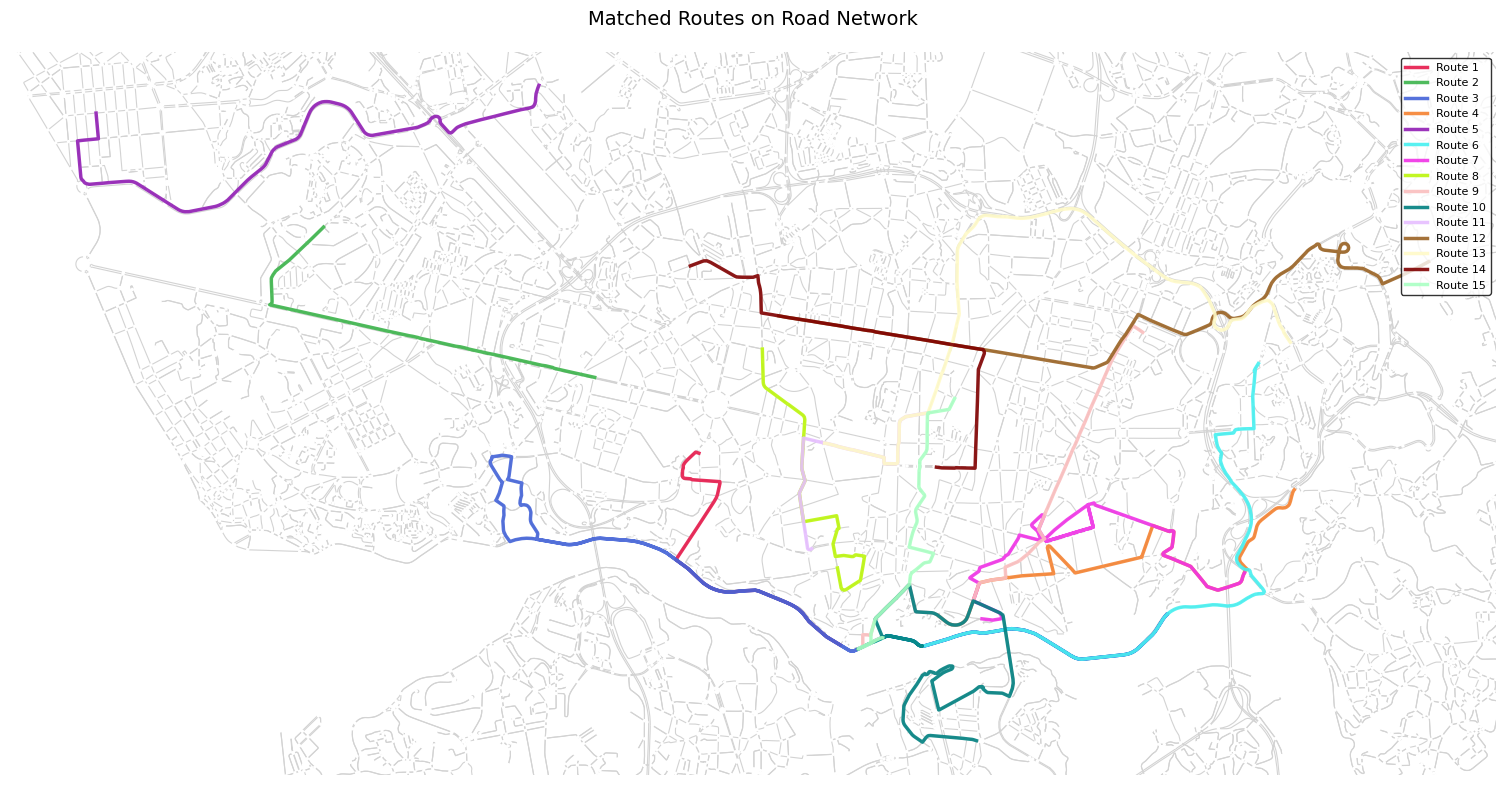

In [9]:
edges ={ (t[0],t[1],t[2]):t[3]['geometry'] for t in G.edges(data=True, keys=True)} # G.edges(data=True, keys=True) returns a 3 tuple, start_id, end_id, key, ddict, convert it to 

routes_edges = []
link_counts = {}
lineString:LineString
for i, route in enumerate(routes): 
    xx, yy = [], [] 
    for link in route: # each link is start, end, key
        try:
            link_counts[(link.start, link.end, link.key)] +=1
        except:
            link_counts[(link.start, link.end, link.key)] = 1

        lineString = edges[(link.start, link.end, link.key)]
        x, y = lineString.xy 
        xx.extend(x) 
        yy.extend(y) 
    routes_edges.append([xx, yy])

# Bounding box of all routes
all_x = np.concatenate([r[0] for r in routes_edges])
all_y = np.concatenate([r[1] for r in routes_edges])
pad_x = (all_x.max() - all_x.min()) * 0.05
pad_y = (all_y.max() - all_y.min()) * 0.05

bbox = (all_y.min() - pad_y, all_y.max() + pad_y,
        all_x.min() - pad_x, all_x.max() + pad_x)
# --- Plot base OSM graph (limited to bbox) ---
fig, ax = ox.plot_graph(
    G_proj,
    bbox=bbox,
    figsize=(15, 8),
    node_size=6,
    node_color="white",
    edge_color="lightgray",
    edge_linewidth=0.8,
    show=False,
    close=False,
)

# --- Plot matched routes ---
for i, route_edge in enumerate(routes_edges):
    color = vivid_colors[i % len(vivid_colors)]
    ax.plot(
        route_edge[0],
        route_edge[1],
        color=color,
        linewidth=2.5,
        alpha=0.9,
        zorder=3,
        label=f"Route {i+1}"
    )

# --- Styling ---
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# move title slightly up and ensure it's visible
ax.set_title("Matched Routes on Road Network", fontsize=14, pad=20)

ax.legend(
    loc="upper right",
    fontsize=8,
    frameon=True,
    facecolor="white",
    edgecolor="black"
)

ax.set_xlim(all_x.min() - pad_x, all_x.max() + pad_x)
ax.set_ylim(all_y.min() - pad_y, all_y.max() + pad_y)

# ensure tight layout doesn’t crop title
fig.tight_layout(rect=[0, 0, 1, 0.97], pad=0.5)

# --- Save & show ---
fig.savefig("Images/matched_routes_compact_part_4.png", dpi=300)
plt.show()
plt.close(fig)


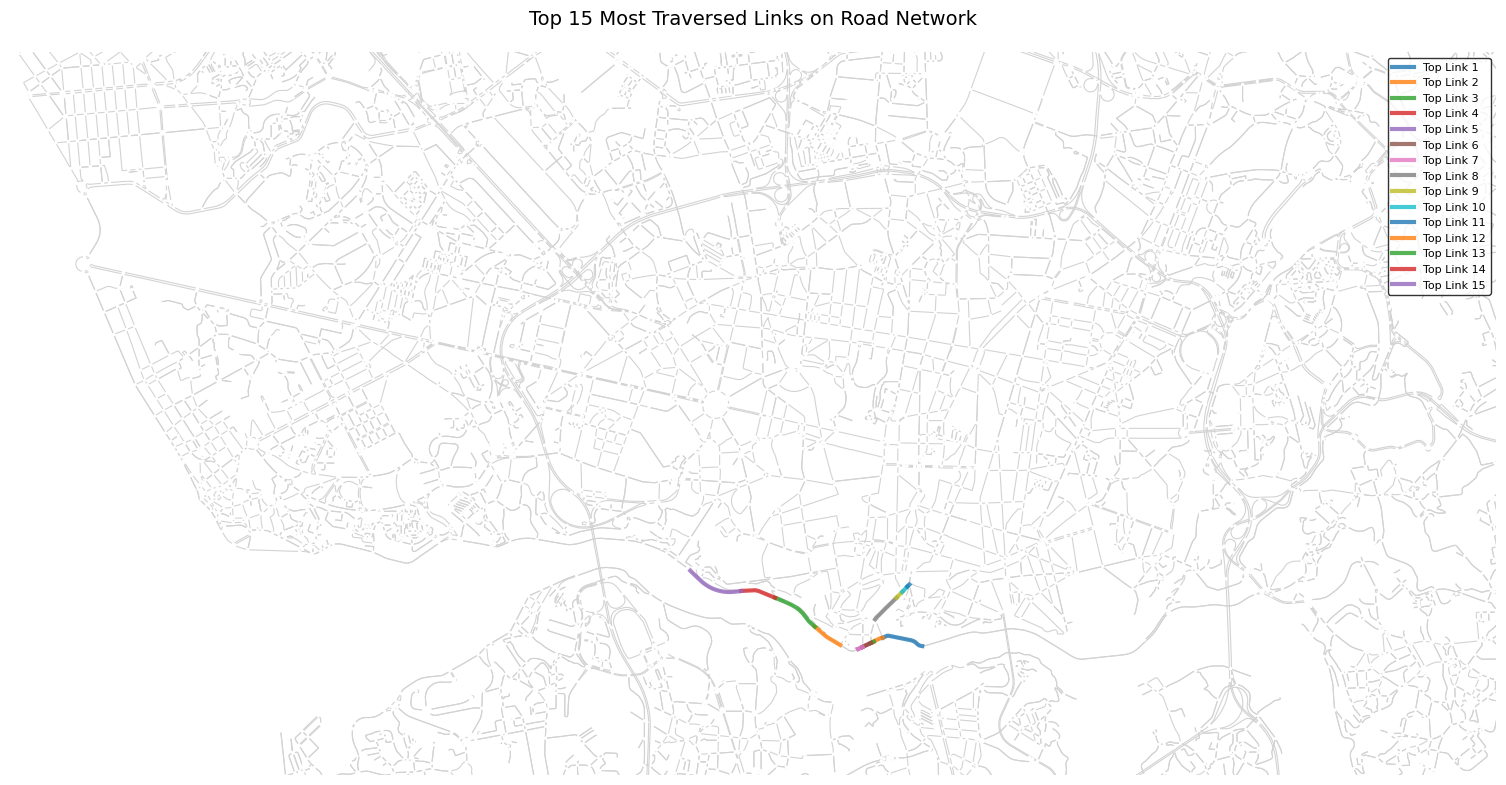

In [10]:
# linkcounts was calculated in the previous box

top_links = sorted(link_counts.items(), key=lambda x: x[1], reverse=True)[:15]
# plot top links
top_links_geom = []
for (start, end, key), count in top_links:
    lineString = edges[(start, end, key)]
    x, y = lineString.xy 
    top_links_geom.append([x,y])

# --- Plot base OSM graph (limited to bbox) ---
fig, ax = ox.plot_graph(
    G_proj,
    bbox=bbox,
    figsize=(15, 8),
    node_size=6,
    node_color="white",
    edge_color="lightgray",
    edge_linewidth=0.8,
    show=False,
    close=False,
)

# --- Plot top links ---
for i, link_geom in enumerate(top_links_geom):
    x, y = link_geom
    ax.plot(
        x, y,
        # color='red',       # highlight top links in red
        linewidth=3,
        alpha=0.8,
        zorder=4,
        label=f"Top Link {i+1}"
    )

# --- Styling ---
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.set_title("Top 15 Most Traversed Links on Road Network", fontsize=14, pad=20)

ax.set_xlim(all_x.min() - pad_x, all_x.max() + pad_x)
ax.set_ylim(all_y.min() - pad_y, all_y.max() + pad_y)

# optional legend (can be omitted if cluttered)
ax.legend(
    loc="upper right",
    fontsize=8,
    frameon=True,
    facecolor="white",
    edgecolor="black"
)

fig.tight_layout(rect=[0, 0, 1, 0.97], pad=0.5)

# Save & show
fig.savefig("Images/top_links_on_network_part_5_1.png", dpi=300)
plt.show()
plt.close(fig)

 1. Link RoadId(start=1548073774, end=114320429, key=0) — average GPS points per trajectory: 10.50
 2. Link RoadId(start=138231423, end=138234198, key=0) — average GPS points per trajectory: 8.50
 3. Link RoadId(start=4612031737, end=428214955, key=0) — average GPS points per trajectory: 7.50
 4. Link RoadId(start=111467271, end=111467270, key=0) — average GPS points per trajectory: 7.00
 5. Link RoadId(start=1771990365, end=1594598177, key=0) — average GPS points per trajectory: 7.00
 6. Link RoadId(start=314074370, end=314074571, key=0) — average GPS points per trajectory: 6.00
 7. Link RoadId(start=111459776, end=111459759, key=0) — average GPS points per trajectory: 5.00
 8. Link RoadId(start=1143316499, end=1143318399, key=0) — average GPS points per trajectory: 5.00
 9. Link RoadId(start=343646769, end=2206192845, key=0) — average GPS points per trajectory: 4.50
10. Link RoadId(start=137884299, end=2222393782, key=0) — average GPS points per trajectory: 4.00
11. Link RoadId(start

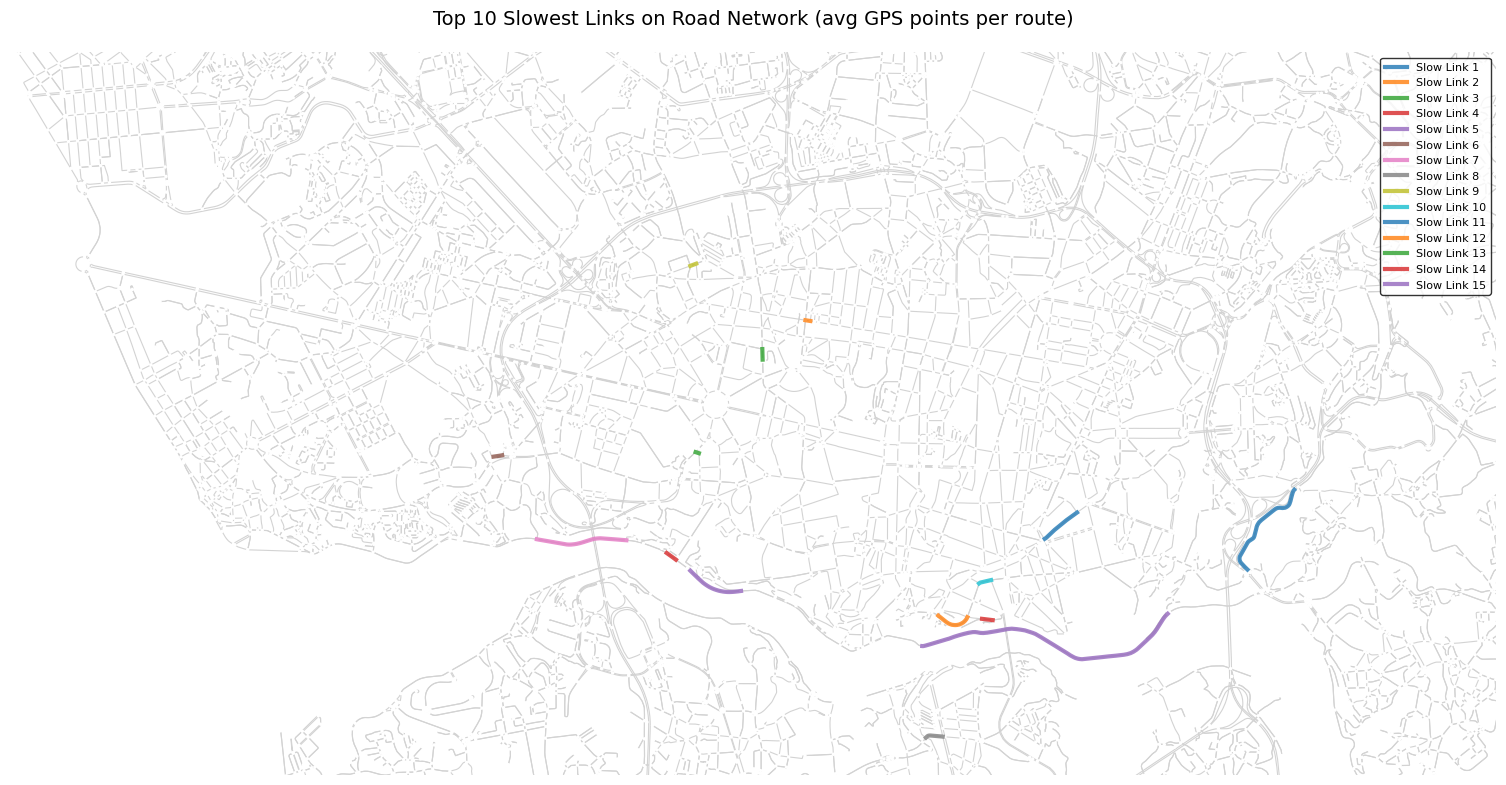

In [11]:
# Container: link_id -> [total_points, total_routes]
link_stats = defaultdict(lambda: [0, 0])
N = 15

# Iterate over trajectories
for traj_df in matches_dfs:
    # Count GPS points per link in this trajectory
    traj_links = traj_df['road_id'].value_counts().astype(float)  # link -> number of GPS points in this traj
    
    # Subtract 0.5 from first and last road_id
    first_link = traj_df.iloc[0]['road_id']
    last_link = traj_df.iloc[-1]['road_id']
    traj_links[first_link] -= 0.5
    traj_links[last_link] -= 0.5
    
    # Accumulate points and route count
    for link, count in traj_links.items():
        link_stats[link][0] += count       # accumulate GPS points
        link_stats[link][1] += 1           # increment number of trajectories that traversed this link

# Compute average GPS points per trajectory for each link
avg_points_per_route = {link: total_points/total_routes
                        for link, (total_points, total_routes) in link_stats.items()}

# Get top 10 links with largest average points per route
top_slowest = sorted(avg_points_per_route.items(), key=lambda x: x[1], reverse=True)[:N]

# Display results
for rank, (link, avg_points) in enumerate(top_slowest, start=1):
    print(f"{rank:2d}. Link {link} — average GPS points per trajectory: {avg_points:.2f}")


# top_slowest is a list of tuples: (link_id, avg_points)
top_slowest_geom = []
for link_id, avg_points in top_slowest:
    lineString = edges[link_id]
    x, y = lineString.xy
    top_slowest_geom.append([x, y])

# --- Plot base OSM graph (limited to bbox) ---
fig, ax = ox.plot_graph(
    G_proj,
    bbox=bbox,
    figsize=(15, 8),
    node_size=6,
    node_color="white",
    edge_color="lightgray",
    edge_linewidth=0.8,
    show=False,
    close=False,
)

# --- Plot top slowest links ---
for i, link_geom in enumerate(top_slowest_geom):
    x, y = link_geom
    ax.plot(
        x, y,
        linewidth=3,
        alpha=0.8,
        zorder=4,
        label=f"Slow Link {i+1}"
    )

# --- Styling ---
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.set_title("Top 10 Slowest Links on Road Network (avg GPS points per route)", fontsize=14, pad=20)

ax.set_xlim(all_x.min() - pad_x, all_x.max() + pad_x)
ax.set_ylim(all_y.min() - pad_y, all_y.max() + pad_y)

# optional legend
ax.legend(
    loc="upper right",
    fontsize=8,
    frameon=True,
    facecolor="white",
    edgecolor="black"
)

fig.tight_layout(rect=[0, 0, 1, 0.97], pad=0.5)

# Save & show
fig.savefig("Images/top_slowest_links_part_5_2.png", dpi=300)
plt.show()
plt.close(fig)

